# name-me — manual ML sanity check

This notebook loads the **exact same code and artifacts the running app uses** — the real
`nameme` package, the real committed `written_similarity`/`cultural_similarity` models, the
real corpus — and lets you poke at the ML logic directly: compare arbitrary name pairs,
run full searches with filters, and eyeball the 2D map. Nothing here is reimplemented; if a
result looks wrong here, it's wrong in the app too (and vice versa).

**Run this from the `backend/` directory** so the kernel uses the project's own `.venv`
(where `nameme` is installed) — see `notebooks/README.md` for the exact launch command.

Run cells top to bottom once, then jump back into any section, edit the names/filters, and
re-run just that cell.

In [1]:
try:
    import nameme  # noqa: F401
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "Couldn't import `nameme`. This notebook must run with the backend's own uv-managed "
        "kernel -- see notebooks/README.md for the launch command (uv run jupyter lab, from "
        "inside backend/)."
    ) from e

import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

from nameme.config import ARTIFACTS_DIR
from nameme.corpus.loader import load_corpus_store
from nameme.services.search_service import search

pd.set_option("display.max_rows", 30)

print("Loading corpus + both models (real committed artifacts, same as production)...")
store = load_corpus_store(ARTIFACTS_DIR)
print("Done.")

Loading corpus + both models (real committed artifacts, same as production)...


Done.


## Corpus overview

In [2]:
print(f"Corpus size: {store.corpus_size:,} unique names")
print(f"Year-range data: {store.year_min}-{store.year_max}")
for model_id, model_store in store.models.items():
    n, dim = model_store.vectors.shape
    print(f"  {model_id}: {n:,} vectors, dim={dim}")

print("\nA few random names, for a feel of the corpus:")
print(store.names_by_popularity[:5], "...", store.names_by_popularity[-5:])

Corpus size: 19,882 unique names
Year-range data: 1949-2024
  written_similarity: 19,882 vectors, dim=100
  cultural_similarity: 19,882 vectors, dim=384

A few random names, for a feel of the corpus:
['מוחמד', 'יוסף', 'דוד', 'משה', 'דניאל'] ... ['תנוך', 'תספה', 'תריד', 'תריק', 'תרקי']


## 1. Direct embedding sanity checks

The lowest-level check: encode two bare names through a model and look at their cosine
similarity directly, bypassing search/filters/ranking entirely. Higher = the model thinks
they're more alike. Edit `PAIRS_TO_CHECK` and re-run.

- `written_similarity` should score high for *spelling*-similar pairs.
- `cultural_similarity` should score high for *culturally/biblically*-linked pairs, even
  when spelled completely differently (this is the model whose whole premise is unproven —
  see `PLAN.md`'s "Sanity check" section for the full story and honest caveats).

In [3]:
def compare(name_a: str, name_b: str, model: str = "written_similarity") -> float:
    embedder = store.model(model).embedder
    va, vb = embedder.encode([name_a]), embedder.encode([name_b])
    sim = float(cosine_similarity(va, vb)[0, 0])
    print(f"{model:20s} sim({name_a!r}, {name_b!r}) = {sim:.3f}")
    return sim


print("-- written_similarity: spelling-similar pairs --")
compare("דוד", "דודי", "written_similarity")
compare("שרה", "שרון", "written_similarity")
compare("משה", "מיכאל", "written_similarity")

print("\n-- cultural_similarity: culturally-linked (but differently-spelled) pairs --")
compare("שרה", "רבקה", "cultural_similarity")   # biblical matriarchs
compare("רות", "נעמי", "cultural_similarity")   # Megillat Rut
compare("דוד", "שלמה", "cultural_similarity")   # father/son biblical kings
compare("אברהם", "יצחק", "cultural_similarity") # father/son patriarchs

print("\n-- cultural_similarity: vs. an unrelated control (אלמוג) --")
compare("שרה", "אלמוג", "cultural_similarity")
compare("דוד", "אלמוג", "cultural_similarity")

-- written_similarity: spelling-similar pairs --
written_similarity   sim('דוד', 'דודי') = 0.742
written_similarity   sim('שרה', 'שרון') = 0.301
written_similarity   sim('משה', 'מיכאל') = 0.101

-- cultural_similarity: culturally-linked (but differently-spelled) pairs --


cultural_similarity  sim('שרה', 'רבקה') = 0.776
cultural_similarity  sim('רות', 'נעמי') = 0.616
cultural_similarity  sim('דוד', 'שלמה') = 0.749
cultural_similarity  sim('אברהם', 'יצחק') = 0.780

-- cultural_similarity: vs. an unrelated control (אלמוג) --
cultural_similarity  sim('שרה', 'אלמוג') = 0.252
cultural_similarity  sim('דוד', 'אלמוג') = 0.311


0.3109782934188843

## 2. Full search sanity check

This calls `search_service.search()` — the exact function `/api/search` calls — directly,
no HTTP involved. `run_search` wraps it to return a tidy DataFrame. Any keyword `search()`
accepts works here too: `sex`, `sector`, `popularity`, `sort`, `year_min`, `year_max`.

In [4]:
def run_search(liked_names, model="written_similarity", top_k=10, **filters) -> pd.DataFrame:
    response = search(store, liked_names, top_k, model, **filters)
    return pd.DataFrame(
        [
            {
                "name": s.name,
                "similarity": round(s.similarity, 3),
                "sex": s.sex,
                "sectors": ", ".join(s.sectors),
                "popularity": s.popularity,
            }
            for s in response.suggestions
        ]
    )


run_search(["דוד", "יוסף"], model="written_similarity", top_k=10)

,name,similarity,sex,sectors,popularity
0,יוסף-דוד,0.930,M,Jewish,9
1,דן-דוד,0.791,M,Jewish,5
2,דור-דוד,0.754,M,Jewish,10
3,דווד,0.753,M,"Jewish, Muslim",18
4,יעקב-דוד,0.733,M,Jewish,6
5,דיוד,0.717,M,Jewish,6
6,ישי-דוד,0.712,M,Jewish,5
7,דביר-דוד,0.709,M,Jewish,6
8,מתן-דוד,0.694,M,Jewish,9
9,דודו,0.682,M,"Christian-Arab, Jewish, Muslim",525


In [5]:
# Same liked names, cultural_similarity model -- compare the two result sets.
run_search(["דוד", "יוסף"], model="cultural_similarity", top_k=10)

,name,similarity,sex,sectors,popularity
0,יהוסף,0.942,M,Jewish,77
1,בן-יוסף,0.940,M,Jewish,9
2,ג'וזף,0.928,M,"Christian-Arab, Druze, Jewish, Muslim",712
3,ניר-יוסף,0.926,M,Jewish,8
4,יואח,0.918,M,Jewish,11
5,נועם-יוסף,0.914,M,Jewish,6
6,יוהונתן,0.914,M,Jewish,5
7,חיאל,0.904,M,Jewish,14
8,יוסף-יצחק,0.903,M,Jewish,24
9,שמואל,0.903,M,"Christian-Arab, Jewish, Muslim",37645


In [6]:
# "Most different" mode: same ranking, walked from the other end.
run_search(["דוד"], model="written_similarity", top_k=10, sort="dissimilar")

,name,similarity,sex,sectors,popularity
0,כאדי,-0.080,F,Muslim,5
1,גנאדי,-0.078,M,Jewish,2586
2,האדי,-0.077,M,"Christian-Arab, Druze, Muslim",2027
3,פהאדי,-0.076,M,Muslim,6
4,הנאדי,-0.075,F,"Christian-Arab, Druze, Muslim",1473
5,נאדי,-0.067,M,Muslim,68
6,שאדי,-0.066,M,"Christian-Arab, Druze, Jewish, Muslim",5515
7,האדיה,-0.066,F,"Christian-Arab, Druze, Muslim",132
8,הינאדי,-0.065,F,Muslim,5
9,הנידי,-0.065,M,Druze,5


## 3. Visualize on the 2D map

Same idea as the app's scatter plot (liked names as big stars, suggestions as colored/sized dots) but rendered here with matplotlib for a quick visual gut-check.

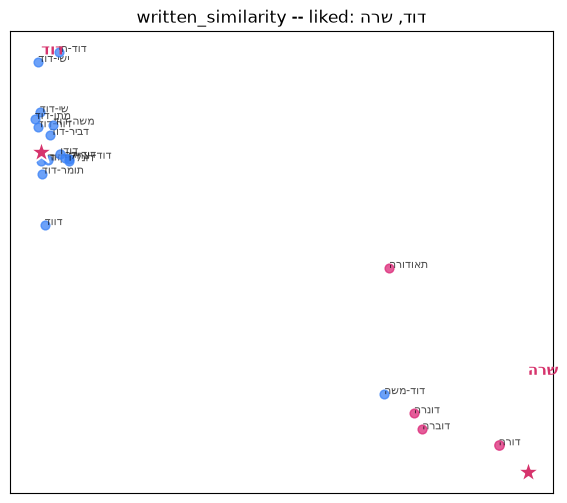

In [7]:
import matplotlib.pyplot as plt

SEX_COLOR = {"M": "#3b82f6", "F": "#db2777"}


def plot_search(liked_names, model="written_similarity", top_k=20, **filters):
    response = search(store, liked_names, top_k, model, **filters)

    fig, ax = plt.subplots(figsize=(7, 6))
    for s in response.suggestions:
        ax.scatter(
            s.x, s.y,
            s=40 + s.popularity / 200,
            color=SEX_COLOR.get(s.sex, "gray"),
            alpha=0.75,
            zorder=2,
        )
        ax.annotate(s.name, (s.x, s.y), fontsize=8, alpha=0.7, zorder=2)

    for p in response.liked:
        ax.scatter(
            p.x, p.y,
            marker="*", s=300,
            color="#d6336c", edgecolor="white", linewidth=1.5,
            zorder=5,
        )
        ax.annotate(
            p.name, (p.x, p.y + 0.01),
            fontsize=11, fontweight="bold", color="#d6336c", zorder=5,
        )

    title = f"{model} -- liked: {', '.join(liked_names)}"
    if filters:
        title += f" -- filters: {filters}"
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()
    return response


_ = plot_search(["דוד", "שרה"], model="written_similarity")

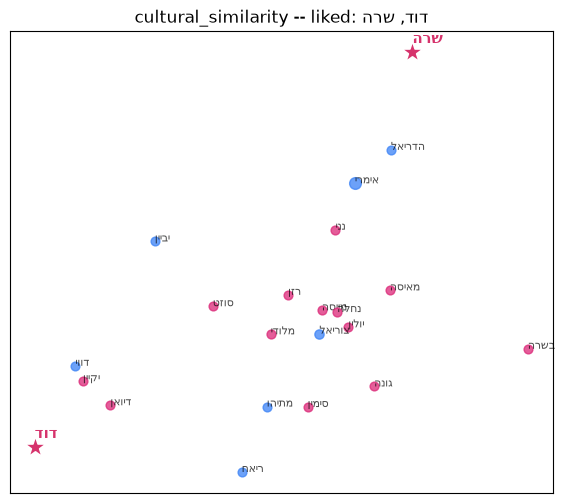

In [8]:
_ = plot_search(["דוד", "שרה"], model="cultural_similarity")

## 4. Filter sanity checks

Interactive versions of the regression tests in `tests/test_corpus_store.py` and
`tests/test_search.py` — each `assert` raises immediately and loudly if something's
actually broken; a silent "OK" print means it checked out. These use real names picked by
querying the actual data (not fabricated), same as the pytest suite.

In [9]:
# Sex filter must catch a name's *non-dominant* sex too, not just the displayed
# "dominant" sex (real bug, fixed -- see PLAN.md Phase 4).
meta = store.meta_for("דניאל")
print(f"דניאל -- dominant sex shown: {meta['sex']!r}, total: {meta['total']:,}")
assert store.matches_sex_sector("דניאל", sex="F", sector="any"), (
    "should still match the non-dominant sex"
)
print("OK: sex filter matches דניאל's non-dominant (female) usage too\n")

# Year-range filter must exclude names with no evidence in the requested range.
old_range = store.year_filtered_meta(1949, 1960)
recent_range = store.year_filtered_meta(2015, 2024)
assert "אילאן" in recent_range and "אילאן" not in old_range
assert "זינובי" in old_range and "זינובי" not in recent_range
print(
    "OK: year-range filter correctly includes/excludes אילאן (2015-2024 only) "
    "and זינובי (1949-1960 only)\n"
)

# Sex+sector are checked TOGETHER, not independently.
combos = store.meta_for("דניאל")["combos"]
print(f"דניאל's real (sex, sector) combinations: {sorted(combos)}")

דניאל -- dominant sex shown: 'M', total: 75,693
OK: sex filter matches דניאל's non-dominant (female) usage too



OK: year-range filter correctly includes/excludes אילאן (2015-2024 only) and זינובי (1949-1960 only)

דניאל's real (sex, sector) combinations: [('F', 'Christian-Arab'), ('F', 'Jewish'), ('F', 'Muslim'), ('M', 'Christian-Arab'), ('M', 'Druze'), ('M', 'Jewish'), ('M', 'Muslim')]


## 5. Try your own

Edit freely and re-run.

In [10]:
run_search(["נועה"], model="written_similarity", top_k=15, sex="F", popularity="top_10_percent")

,name,similarity,sex,sectors,popularity
0,נוף,0.856,F,"Druze, Jewish, Muslim",501
1,נועם,0.850,M,"Druze, Jewish, Muslim",55462
2,נגה,0.737,F,"Druze, Jewish, Muslim",13953
3,נוה,0.677,M,"Jewish, Muslim",5572
4,נטע,0.669,F,Jewish,16150
5,נוי,0.635,F,"Christian-Arab, Druze, Jewish, Muslim",8122
6,נופר,0.633,F,Jewish,7628
7,ניצה,0.628,F,Jewish,2003
8,נבו,0.622,M,Jewish,5169
9,נורה,0.620,F,"Christian-Arab, Druze, Jewish, Muslim",3746
